# IMPORTING LIBRARIES AND DATA

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import ListedColormap
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [1]:
import pandas as pd

file_path = '/content/drive/MyDrive/accepted_2007_to_2018Q4.csv'


In [2]:
df = pd.read_csv(file_path, low_memory=False)

# EXPLORATORY DATA ANALYSIS

In [4]:
print(f"Loaded dataset with shape: {df.shape}")

# Filter to completed loans only
completed_statuses = [
    'Fully Paid', 'Charged Off', 'Default',
    'Late (31-120 days)', 'Late (16-30 days)',
    'Does not meet the credit policy. Status:Fully Paid',
    'Does not meet the credit policy. Status: Charged Off'
]

df = df[df['loan_status'].isin(completed_statuses)].copy()
print(f"Filtered to completed loans: {df.shape[0]:,} rows")

# Show distribution
print("\nLoan status distribution:")
print(df['loan_status'].value_counts())

print(f"\nFinal dataset after filtering: {df.shape}")

Loaded dataset with shape: (2260701, 151)
Filtered to completed loans: 1,373,154 rows

Loan status distribution:
loan_status
Fully Paid                                            1076751
Charged Off                                            268559
Late (31-120 days)                                      21467
Late (16-30 days)                                        4349
Does not meet the credit policy. Status:Fully Paid       1988
Default                                                    40
Name: count, dtype: int64

Final dataset after filtering: (1373154, 151)


In [5]:
# Convert loan_status to binary (0=paid, 1=default)
status_map = {
    'Fully Paid': 0, 'Charged Off': 1, 'Default': 1,
    'Late (31-120 days)': 1, 'Late (16-30 days)': 1,
    'Does not meet the credit policy. Status:Fully Paid': 0,
    'Does not meet the credit policy. Status:Charged Off': 1
}

print("\nBinary mapping:")
print("  0: Paid (Fully Paid, Policy-Fully Paid)")
print("  1: Default (Charged Off, Default, Late, Policy-Charged Off)")

df['loan_status_binary'] = df['loan_status'].map(status_map).astype(int)

# Class distribution
class_dist = df['loan_status_binary'].value_counts().sort_index()

print(f"\nClass distribution:")
for cls, count in class_dist.items():
    label = "Paid" if cls == 0 else "Default"
    print(f"  {cls} ({label}): {count:,} ({count/len(df)*100:.1f}%)")


Binary mapping:
  0: Paid (Fully Paid, Policy-Fully Paid)
  1: Default (Charged Off, Default, Late, Policy-Charged Off)

Class distribution:
  0 (Paid): 1,078,739 (78.6%)
  1 (Default): 294,415 (21.4%)


In [6]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,loan_status_binary
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
5,68426831,NaN,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0


In [7]:
print("Dataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistics:")
df.describe()

,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,...,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term,loan_status_binary
count,0.0,1.373154e+06,1.373154e+06,1.373154e+06,1.373154e+06,1.373154e+06,1.373150e+06,1.372751e+06,1.373128e+06,1.373154e+06,...,7631.00000,7631.0,7631.000000,5451.000000,7631.000000,7631.000000,34198.000000,34198.000000,34198.000000,1.373154e+06
mean,NaN,1.446082e+04,1.445232e+04,1.442699e+04,1.328514e+01,4.390681e+02,7.626337e+04,1.830978e+01,3.186076e-01,6.961016e+02,...,153.45325,3.0,14.515005,441.783528,11373.131381,192.631862,5009.942763,47.766837,13.194924,2.144079e-01
std,NaN,8.743655e+03,8.739889e+03,8.744737e+03,4.788256e+00,2.621674e+02,7.026864e+04,1.132362e+01,8.800274e-01,3.180987e+01,...,131.54247,0.0,9.451345,378.787841,7629.284695,198.198606,3689.934458,7.299424,8.161496,4.104111e-01
min,NaN,5.000000e+02,5.000000e+02,0.000000e+00,5.310000e+00,4.930000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,6.100000e+02,...,0.64000,3.0,0.000000,1.920000,55.730000,0.010000,44.210000,0.200000,0.000000,0.000000e+00
25%,NaN,8.000000e+03,8.000000e+03,7.925000e+03,9.750000e+00,2.490100e+02,4.575000e+04,1.180000e+01,0.000000e+00,6.700000e+02,...,55.83000,3.0,7.000000,161.460000,5277.805000,45.255000,2208.370000,45.000000,6.000000,0.000000e+00
50%,NaN,1.200000e+04,1.200000e+04,1.200000e+04,1.279000e+01,3.754300e+02,6.500000e+04,1.763000e+01,0.000000e+00,6.900000e+02,...,114.74000,3.0,16.000000,330.990000,9659.450000,130.660000,4147.000000,45.000000,14.000000,0.000000e+00
75%,NaN,2.000000e+04,2.000000e+04,2.000000e+04,1.602000e+01,5.820375e+02,9.000000e+04,2.408000e+01,0.000000e+00,7.100000e+02,...,213.62000,3.0,23.000000,603.975000,15965.080000,280.230000,6850.320000,50.000000,18.000000,0.000000e+00
max,NaN,4.000000e+04,4.000000e+04,4.000000e+04,3.099000e+01,1.719830e+03,1.099920e+07,9.990000e+02,3.900000e+01,8.450000e+02,...,943.94000,3.0,37.000000,2679.150000,39542.450000,1407.860000,33601.000000,521.350000,181.000000,1.000000e+00


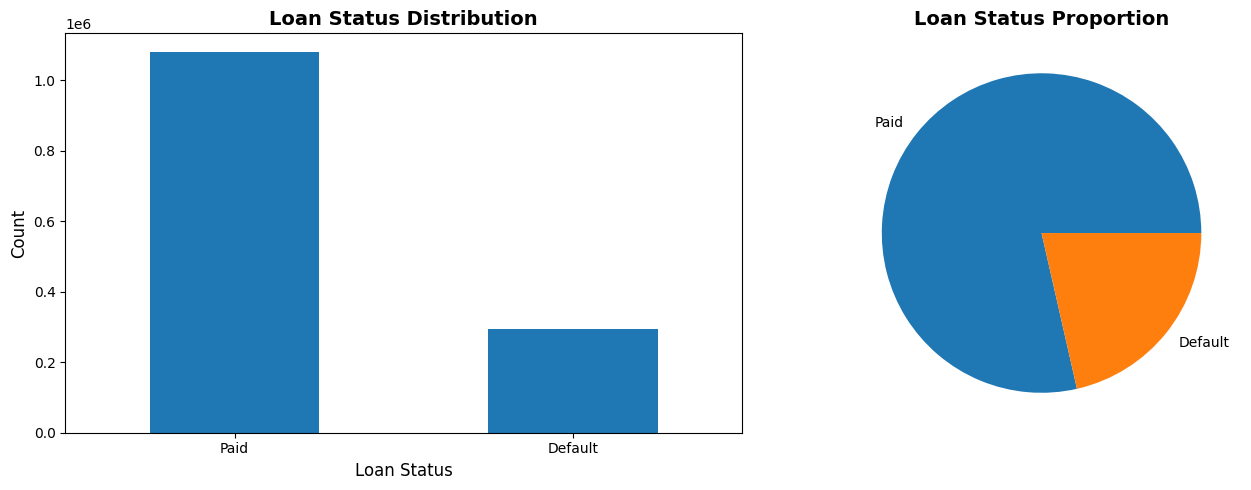


Class Distribution:
  Paid:    1,078,739 (78.6%)
  Default: 294,415 (21.4%)
  Default Rate: 21.44%


In [9]:
#Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
value_counts = df['loan_status_binary'].value_counts().sort_index()
value_counts.plot(kind='bar', ax=axes[0])
axes[0].set_title('Loan Status Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Loan Status', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)

# Set tick labels dynamically based on available classes
tick_labels = ['Paid' if i == 0 else 'Default' for i in value_counts.index]
axes[0].set_xticklabels(tick_labels, rotation=0)

# Pie chart
value_counts.plot(kind='pie', ax=axes[1],
                  labels=tick_labels)
axes[1].set_title('Loan Status Proportion', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print(f"\nClass Distribution:")
print(f"  Paid:    {(df['loan_status_binary']==0).sum():,} ({(df['loan_status_binary']==0).mean()*100:.1f}%)")
print(f"  Default: {(df['loan_status_binary']==1).sum():,} ({(df['loan_status_binary']==1).mean()*100:.1f}%)")
print(f"  Default Rate: {df['loan_status_binary'].mean()*100:.2f}%")

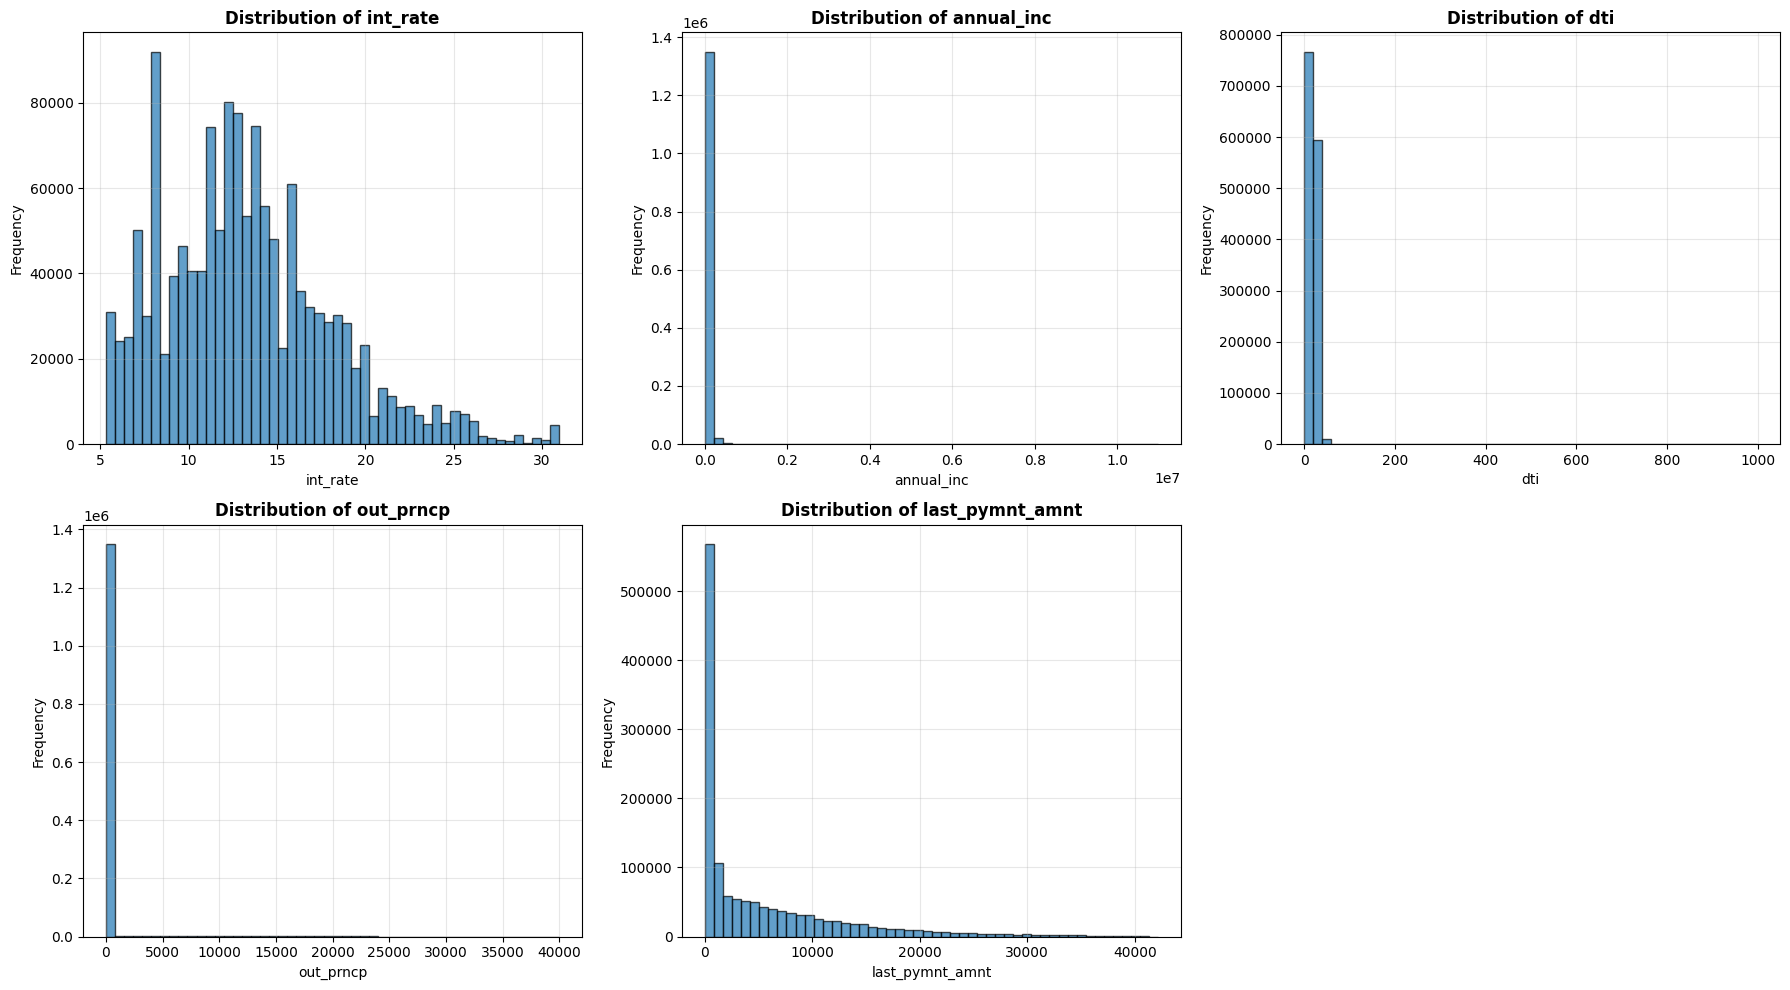

In [10]:
# Distribution of key numerical features

potential_numerical = ['int_rate', 'annual_inc', 'dti', 'fico_score', 'out_prncp', 'last_pymnt_amnt']
numerical_features = [f for f in potential_numerical if f in df.columns]


fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_features):
    if idx < len(axes):
        axes[idx].hist(df[col], bins=50, alpha=0.7, edgecolor='black')
        axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col, fontsize=10)
        axes[idx].set_ylabel('Frequency', fontsize=10)
        axes[idx].grid(alpha=0.3)

# Hide unused subplots
for idx in range(len(numerical_features), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

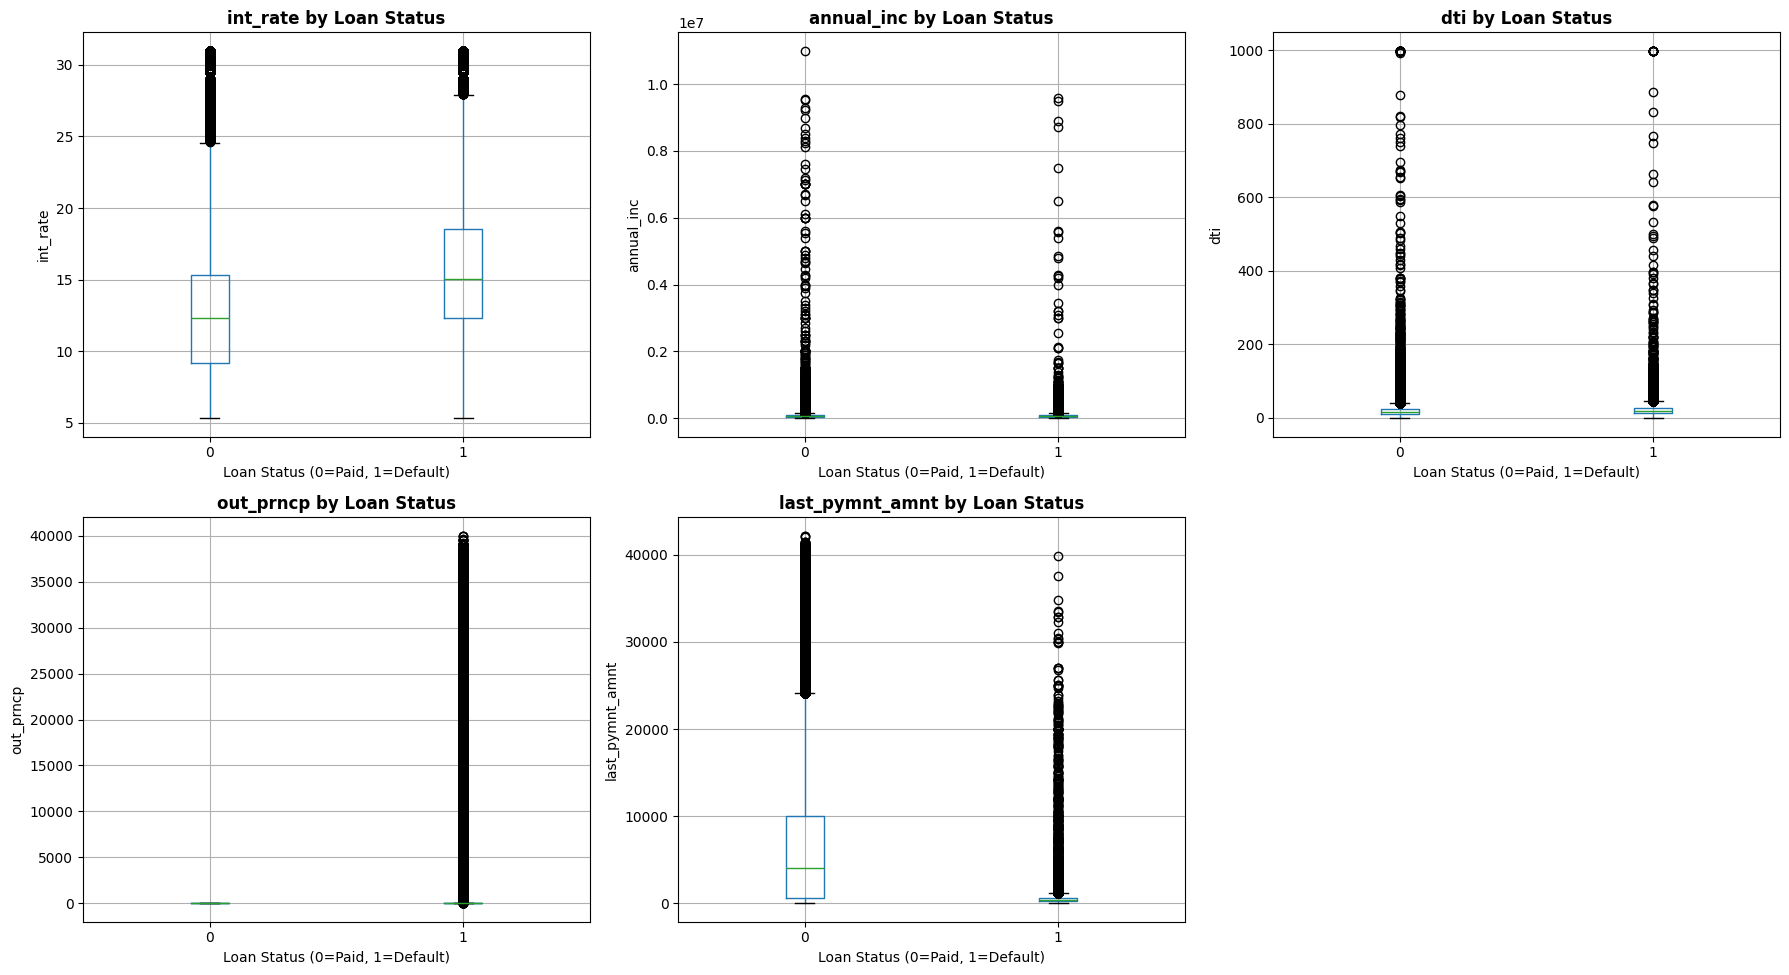

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_features):
    if idx < len(axes):
        df.boxplot(column=col, by='loan_status_binary', ax=axes[idx])
        axes[idx].set_title(f'{col} by Loan Status', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Loan Status (0=Paid, 1=Default)', fontsize=10)
        axes[idx].set_ylabel(col, fontsize=10)

# Skip unused Plots
for idx in range(len(numerical_features), len(axes)):
    axes[idx].axis('off')

plt.suptitle('')
plt.tight_layout()
plt.show()

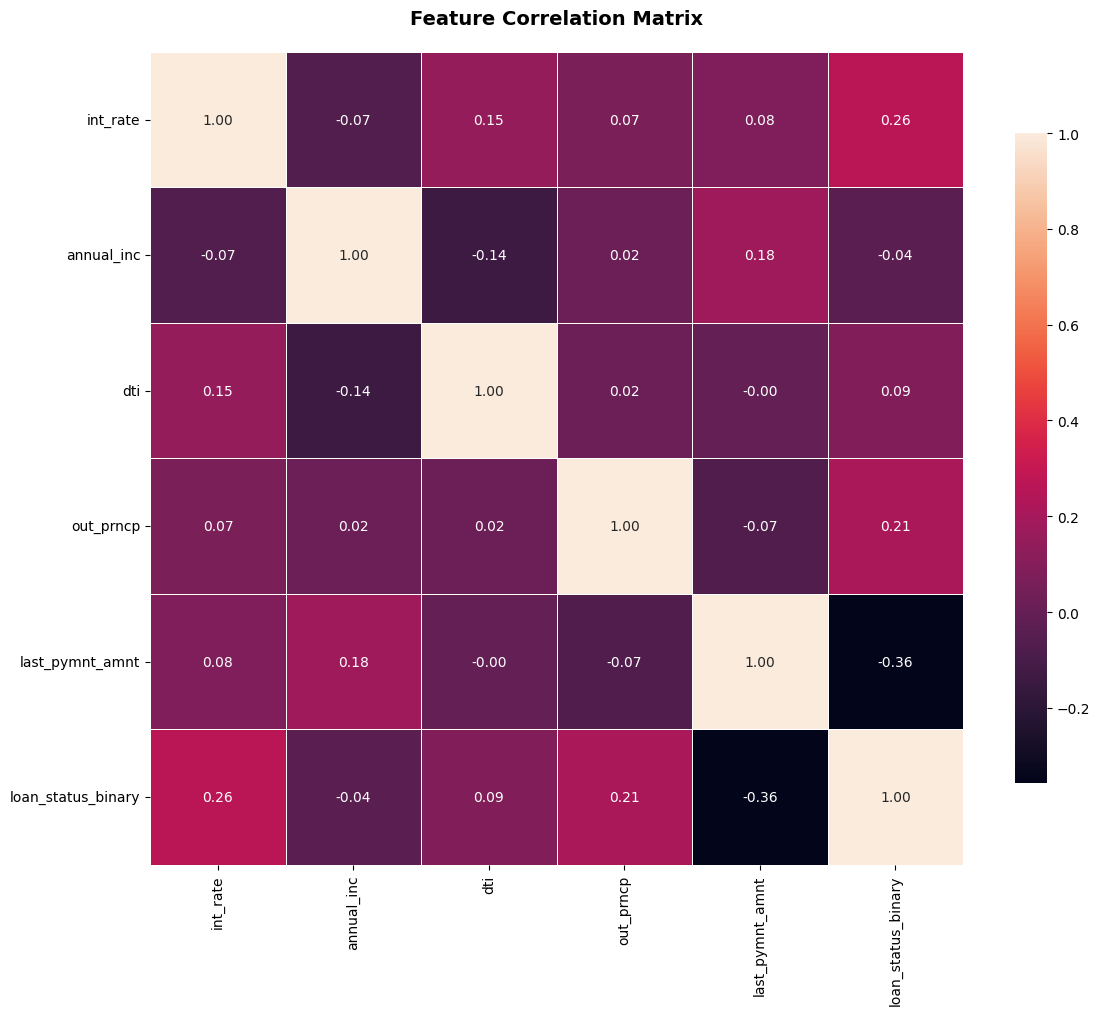

In [14]:
plt.figure(figsize=(12, 10))
correlation_matrix = df[numerical_features + ['loan_status_binary']].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f',
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# DATA PREPROCESSING

In [15]:
# STEP 1: CLEANING STRING COLUMNS

# Interest rate: '10.5%' to 0.105
if df['int_rate'].dtype == 'object':
    df['int_rate'] = df['int_rate'].str.rstrip('%').astype('float') / 100

# Revolving utilisation: '85.5%' to 85.5
if 'revol_util' in df.columns and df['revol_util'].dtype == 'object':
    df['revol_util'] = df['revol_util'].str.rstrip('%').astype('float')

# Employment length: '10+ years' to 10
if 'emp_length' in df.columns and df['emp_length'].dtype == 'object':
    df['emp_length'] = df['emp_length'].str.extract('(\d+)').fillna(0).astype(int)


# Loan term: ' 36 months' to 36
if 'term' in df.columns and df['term'].dtype == 'object':
    df['term'] = df['term'].str.extract('(\d+)').fillna(0).astype(int)

In [15]:
# STEP 2: CREATING UNIFIED FICO SCORE"

# The dataset has multiple FICO columns, let's unify them
fico_cols = [col for col in df.columns if 'fico' in col.lower()]

if fico_cols:
    # we have a range
    if 'fico_range_low' in df.columns and 'fico_range_high' in df.columns:
        df['fico_score'] = (df['fico_range_low'] + df['fico_range_high']) / 2
    # Otherwise
    elif len(fico_cols) > 0:
        df['fico_score'] = df[fico_cols[0]]
else:
    # No FICO data, let's handle it
    df['fico_score'] = 700  #(default value = 700 US average)


In [16]:
# STEP 3: FEATURE SELECTION & VALIDATION


# These are the features we'd LIKE to use
desired_features = {
    # Numeric features
    'loan_amnt': 'Loan amount requested','int_rate': 'Interest rate','instalment': 'Monthly payment','annual_inc': 'Annual income',
    'dti': 'Debt-to-income ratio','fico_score': 'FICO credit score','revol_bal': 'Revolving balance','revol_util': 'Revolving utilisation %',
    'out_prncp': 'Outstanding principal','last_pymnt_amnt': 'Last payment amount','tot_cur_bal': 'Total current balance',
    'total_rev_hi_lim': 'Total revolving limit','emp_length': 'Employment length (years)',
    # Categorical features
    'home_ownership': 'Home ownership status','purpose': 'Loan purpose'}

available = []
missing = []

for feature, description in desired_features.items():
    if feature in df.columns:
        available.append(feature)
        print(f" {feature:<25} {description}")
    else:
        missing.append(feature)
        print(f" {feature:<25} {description} [NOT FOUND]")

 loan_amnt                 Loan amount requested
 int_rate                  Interest rate
 instalment                Monthly payment [NOT FOUND]
 annual_inc                Annual income
 dti                       Debt-to-income ratio
 fico_score                FICO credit score [NOT FOUND]
 revol_bal                 Revolving balance
 revol_util                Revolving utilisation %
 out_prncp                 Outstanding principal
 last_pymnt_amnt           Last payment amount
 tot_cur_bal               Total current balance
 total_rev_hi_lim          Total revolving limit
 emp_length                Employment length (years)
 home_ownership            Home ownership status
 purpose                   Loan purpose


In [18]:
# STEP 4: HANDLING MISSING VALUES

# Check each available feature for nulls
missing_info = df[available].isnull().sum()
features_with_nulls = missing_info[missing_info > 0]

if len(features_with_nulls) > 0:
    for feature, null_count in features_with_nulls.items():
        null_pct = (null_count / len(df)) * 100

    # Numeric features: fill with median
    numeric_features = df[available].select_dtypes(include=[np.number]).columns
    for col in numeric_features:
        if df[col].isnull().sum() > 0:
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)


    # Categorical features: fill with mode
    categorical_features = df[available].select_dtypes(include=['object']).columns
    for col in categorical_features:
        if df[col].isnull().sum() > 0:
            mode_val = df[col].mode()[0]
            df[col] = df[col].fillna(mode_val)

In [21]:
# STEP 5: ENCODING CATEGORICAL VARIABLES

categorical_to_encode = ['home_ownership', 'purpose']
encoded_columns = []

for cat_feature in categorical_to_encode:
    if cat_feature in available:
        # Create a label encoder
        le = LabelEncoder()

        # Encode the feature
        encoded_name = f'{cat_feature}_encoded'
        df[encoded_name] = le.fit_transform(df[cat_feature])
        encoded_columns.append(encoded_name)

        # Show what we did
        n_categories = len(le.classes_)


In [22]:
# STEP 6: FINALIZING FEATURE SET")

# Our final features = numeric features + encoded categorical features
numeric_features = [f for f in available if f not in categorical_to_encode]
final_features = numeric_features + encoded_columns

In [33]:
# STEP 7: TRAIN-TEST SPLIT"

X = df[final_features].copy()
y = df['loan_status_binary'].copy()

print("Target Distribution (Overall):")
for class_val in sorted(y.unique()):
    count = (y == class_val).sum()
    pct = (y == class_val).mean() * 100
    label = "Paid" if class_val == 0 else "Default"
    print(f"   {class_val} ({label:<7}): {count:>8,} samples ({pct:>5.1f}%)")

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3, random_state=42)

print(f"\nTrain set size: {X_train.shape[0]:,} samples")
print(f"Test set size:  {X_test.shape[0]:,} samples")

Target Distribution (Overall):
   0 (Paid   ): 1,078,739 samples ( 78.6%)
   1 (Default):  294,415 samples ( 21.4%)

Train set size: 961,207 samples
Test set size:  411,947 samples


# MODELS TRAINING

In [42]:
# Initialize models
models = {
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss'),
    'CatBoost': CatBoostClassifier(iterations=100, depth=6, learning_rate=0.1, random_state=42, verbose=0),
    'RandomForest': RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
}

# Initialize dictionaries to store results
results = {}
trained_models = {}
confusion_matrices = {}

print("Models and result dictionaries initialized.")

Models and result dictionaries initialized.


In [51]:
from sklearn.tree import DecisionTreeClassifier

# Add DecisionTreeClassifier to the models dictionary
models['DecisionTree'] = DecisionTreeClassifier(random_state=42)

print("DecisionTreeClassifier added to models dictionary.")

DecisionTreeClassifier added to models dictionary.


## 1. DECISION TREE

In [44]:
name = 'DecisionTree'
model = models[name]

print(f"\n{name}:")

# Create copies to process without altering original X_train, X_test
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

# Ensure 'emp_length' is numeric, as indicated by previous errors
if 'emp_length' in X_train_processed.columns and X_train_processed['emp_length'].dtype == 'object':
    # Convert to numeric, coercing non-numeric values to NaN
    X_train_processed['emp_length'] = pd.to_numeric(X_train_processed['emp_length'], errors='coerce')
    X_test_processed['emp_length'] = pd.to_numeric(X_test_processed['emp_length'], errors='coerce')

    # Fill any NaNs that might have resulted from conversion or were present
    median_emp_length = X_train_processed['emp_length'].median()
    X_train_processed['emp_length'].fillna(median_emp_length, inplace=True);
    X_test_processed['emp_length'].fillna(median_emp_length, inplace=True);

model.fit(X_train_processed, y_train)

# Predictions
y_pred = model.predict(X_test_processed)
y_pred_proba = model.predict_proba(X_test_processed)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)

# Cross-validation (using processed data)
cv_scores = cross_val_score(model, X_train_processed, y_train, cv=5, scoring='roc_auc')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
confusion_matrices[name] = cm

results[name] = {
    'Accuracy': accuracy,
    'AUC': auc,
    'F1-Score': f1,
    'CV AUC Mean': cv_scores.mean(),
    'CV AUC Std': cv_scores.std()
}

trained_models[name] = model

# Print Summary
print(f"  Accuracy:     {accuracy:.4f}")
print(f"  AUC:          {auc:.4f}")
print(f"  F1-Score:     {f1:.4f}")
print(f"  CV AUC:       {cv_scores.mean():.4f} (\u00b1{cv_scores.std():.4f})")

print(f"\n  Confusion Matrix: TN={cm[0,0]:,} | FP={cm[0,1]:,} | FN={cm[1,0]:,} | TP={cm[1,1]:,}")

print(f"\n  Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Paid', 'Default']))

print(f"\n{name} model trained and evaluated successfully.")


DecisionTree:
  Accuracy:     0.8898
  AUC:          0.8381
  F1-Score:     0.7441
  CV AUC:       0.8297 (±0.0025)

  Confusion Matrix: TN=300,488 | FP=23,115 | FN=22,301 | TP=66,043

  Classification Report:
              precision    recall  f1-score   support

        Paid       0.93      0.93      0.93    323603
     Default       0.74      0.75      0.74     88344

    accuracy                           0.89    411947
   macro avg       0.84      0.84      0.84    411947
weighted avg       0.89      0.89      0.89    411947


DecisionTree model trained and evaluated successfully.


## 2. XGBOOST

In [45]:
name = 'XGBoost'
model = models[name]

print(f"\n{name}:")

# Create copies to process without altering original X_train, X_test
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

# Ensure 'emp_length' is numeric, as indicated by previous errors
if 'emp_length' in X_train_processed.columns and X_train_processed['emp_length'].dtype == 'object':
    # Convert to numeric, coercing non-numeric values to NaN
    X_train_processed['emp_length'] = pd.to_numeric(X_train_processed['emp_length'], errors='coerce')
    X_test_processed['emp_length'] = pd.to_numeric(X_test_processed['emp_length'], errors='coerce')

    # Fill any NaNs that might have resulted from conversion or were present
    median_emp_length = X_train_processed['emp_length'].median()
    X_train_processed['emp_length'].fillna(median_emp_length, inplace=True);
    X_test_processed['emp_length'].fillna(median_emp_length, inplace=True);

model.fit(X_train_processed, y_train)

# Predictions
y_pred = model.predict(X_test_processed)
y_pred_proba = model.predict_proba(X_test_processed)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)

# Cross-validation (using processed data)
cv_scores = cross_val_score(model, X_train_processed, y_train, cv=5, scoring='roc_auc')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
confusion_matrices[name] = cm

results[name] = {
    'Accuracy': accuracy,
    'AUC': auc,
    'F1-Score': f1,
    'CV AUC Mean': cv_scores.mean(),
    'CV AUC Std': cv_scores.std()
}

trained_models[name] = model

# Print Summary
print(f"  Accuracy:     {accuracy:.4f}")
print(f"  AUC:          {auc:.4f}")
print(f"  F1-Score:     {f1:.4f}")
print(f"  CV AUC:       {cv_scores.mean():.4f} (\u00b1{cv_scores.std():.4f})")

print(f"\n  Confusion Matrix: TN={cm[0,0]:,} | FP={cm[0,1]:,} | FN={cm[1,0]:,} | TP={cm[1,1]:,}")

print(f"\n  Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Paid', 'Default']))

print(f"\n{name} model trained and evaluated successfully.")


XGBoost:
  Accuracy:     0.8907
  AUC:          0.9514
  F1-Score:     0.7352
  CV AUC:       0.9519 (±0.0005)

  Confusion Matrix: TN=304,376 | FP=19,227 | FN=25,816 | TP=62,528

  Classification Report:
              precision    recall  f1-score   support

        Paid       0.92      0.94      0.93    323603
     Default       0.76      0.71      0.74     88344

    accuracy                           0.89    411947
   macro avg       0.84      0.82      0.83    411947
weighted avg       0.89      0.89      0.89    411947


XGBoost model trained and evaluated successfully.


## 3. CATBOOST

In [46]:
name = 'CatBoost'
model = models[name]

print(f"\n{name}:")

# Create copies to process without altering original X_train, X_test
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

# Ensure 'emp_length' is numeric, as indicated by previous errors
if 'emp_length' in X_train_processed.columns and X_train_processed['emp_length'].dtype == 'object':
    # Convert to numeric, coercing non-numeric values to NaN
    X_train_processed['emp_length'] = pd.to_numeric(X_train_processed['emp_length'], errors='coerce')
    X_test_processed['emp_length'] = pd.to_numeric(X_test_processed['emp_length'], errors='coerce')

    # Fill any NaNs that might have resulted from conversion or were present
    median_emp_length = X_train_processed['emp_length'].median()
    X_train_processed['emp_length'].fillna(median_emp_length, inplace=True);
    X_test_processed['emp_length'].fillna(median_emp_length, inplace=True);

model.fit(X_train_processed, y_train)

# Predictions
y_pred = model.predict(X_test_processed)
y_pred_proba = model.predict_proba(X_test_processed)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)

# Cross-validation (using processed data)
cv_scores = cross_val_score(model, X_train_processed, y_train, cv=5, scoring='roc_auc')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
confusion_matrices[name] = cm

results[name] = {
    'Accuracy': accuracy,
    'AUC': auc,
    'F1-Score': f1,
    'CV AUC Mean': cv_scores.mean(),
    'CV AUC Std': cv_scores.std()
}

trained_models[name] = model

# Print Summary
print(f"  Accuracy:     {accuracy:.4f}")
print(f"  AUC:          {auc:.4f}")
print(f"  F1-Score:     {f1:.4f}")
print(f"  CV AUC:       {cv_scores.mean():.4f} (\u00b1{cv_scores.std():.4f})")

print(f"\n  Confusion Matrix: TN={cm[0,0]:,} | FP={cm[0,1]:,} | FN={cm[1,0]:,} | TP={cm[1,1]:,}")

print(f"\n  Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Paid', 'Default']))

print(f"\n{name} model trained and evaluated successfully.")


CatBoost:
  Accuracy:     0.8850
  AUC:          0.9478
  F1-Score:     0.7206
  CV AUC:       0.9477 (±0.0006)

  Confusion Matrix: TN=303,518 | FP=20,085 | FN=27,279 | TP=61,065

  Classification Report:
              precision    recall  f1-score   support

        Paid       0.92      0.94      0.93    323603
     Default       0.75      0.69      0.72     88344

    accuracy                           0.89    411947
   macro avg       0.84      0.81      0.82    411947
weighted avg       0.88      0.89      0.88    411947


CatBoost model trained and evaluated successfully.


## 4. RANDOM FOREST

In [47]:
name = 'RandomForest'
model = models[name]

print(f"\n{name}:")

# Create copies to process without altering original X_train, X_test
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

# Ensure 'emp_length' is numeric, as indicated by previous errors
if 'emp_length' in X_train_processed.columns and X_train_processed['emp_length'].dtype == 'object':
    # Convert to numeric, coercing non-numeric values to NaN
    X_train_processed['emp_length'] = pd.to_numeric(X_train_processed['emp_length'], errors='coerce')
    X_test_processed['emp_length'] = pd.to_numeric(X_test_processed['emp_length'], errors='coerce')

    # Fill any NaNs that might have resulted from conversion or were present
    median_emp_length = X_train_processed['emp_length'].median()
    X_train_processed['emp_length'].fillna(median_emp_length, inplace=True);
    X_test_processed['emp_length'].fillna(median_emp_length, inplace=True);

model.fit(X_train_processed, y_train)

# Predictions
y_pred = model.predict(X_test_processed)
y_pred_proba = model.predict_proba(X_test_processed)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)

# Cross-validation (using processed data)
cv_scores = cross_val_score(model, X_train_processed, y_train, cv=5, scoring='roc_auc')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
confusion_matrices[name] = cm

results[name] = {
    'Accuracy': accuracy,
    'AUC': auc,
    'F1-Score': f1,
    'CV AUC Mean': cv_scores.mean(),
    'CV AUC Std': cv_scores.std()
}

trained_models[name] = model

# Print Summary
print(f"  Accuracy:     {accuracy:.4f}")
print(f"  AUC:          {auc:.4f}")
print(f"  F1-Score:     {f1:.4f}")
print(f"  CV AUC:       {cv_scores.mean():.4f} (\u00b1{cv_scores.std():.4f})")

print(f"\n  Confusion Matrix: TN={cm[0,0]:,} | FP={cm[0,1]:,} | FN={cm[1,0]:,} | TP={cm[1,1]:,}")

print(f"\n  Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Paid', 'Default']))

print(f"\n{name} model trained and evaluated successfully.")


RandomForest:
  Accuracy:     0.8590
  AUC:          0.9281
  F1-Score:     0.5726
  CV AUC:       0.9288 (±0.0006)

  Confusion Matrix: TN=314,935 | FP=8,668 | FN=49,423 | TP=38,921

  Classification Report:
              precision    recall  f1-score   support

        Paid       0.86      0.97      0.92    323603
     Default       0.82      0.44      0.57     88344

    accuracy                           0.86    411947
   macro avg       0.84      0.71      0.74    411947
weighted avg       0.85      0.86      0.84    411947


RandomForest model trained and evaluated successfully.


# RESULTS SUMMARY

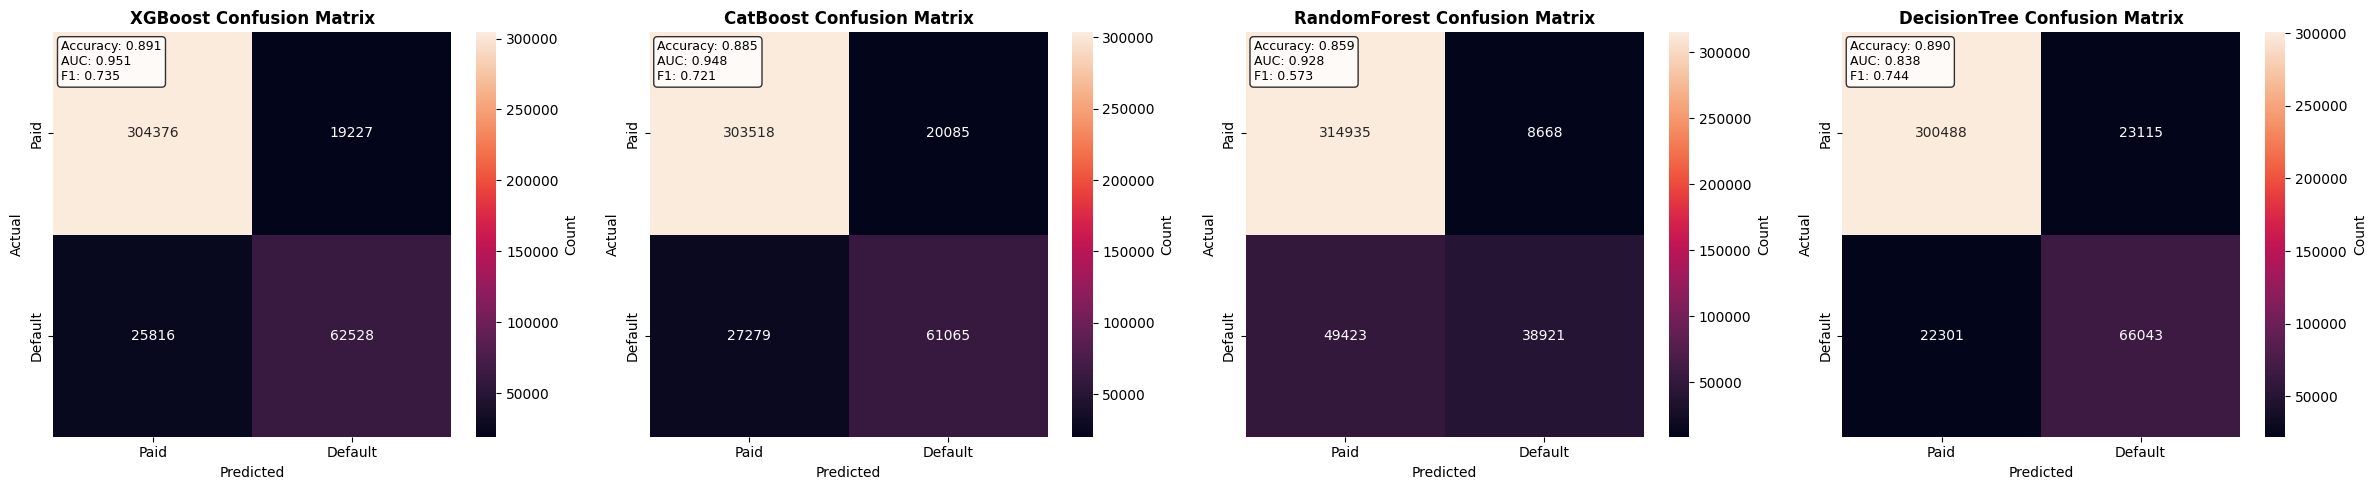

In [49]:
# Visualize Confusion Matrices
fig, axes = plt.subplots(1, 4, figsize=(24, 5)) # Changed to 4 subplots

for idx, (name, cm) in enumerate(confusion_matrices.items()):
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx],
                cbar_kws={'label': 'Count'},
                xticklabels=['Paid', 'Default'],
                yticklabels=['Paid', 'Default'])

    axes[idx].set_title(f'{name} Confusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('Actual', fontsize=10)

    # Add performance metrics as text
    accuracy = results[name]['Accuracy']
    auc = results[name]['AUC']
    f1 = results[name]['F1-Score']

    textstr = f'Accuracy: {accuracy:.3f}\nAUC: {auc:.3f}\nF1: {f1:.3f}'
    axes[idx].text(0.02, 0.98, textstr, transform=axes[idx].transAxes,
                   fontsize=9, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()


Model Performance Comparison:
              Accuracy     AUC  F1-Score  CV AUC Mean  CV AUC Std
XGBoost         0.8907  0.9514    0.7352       0.9519      0.0005
CatBoost        0.8850  0.9478    0.7206       0.9477      0.0006
RandomForest    0.8590  0.9281    0.5726       0.9288      0.0006
DecisionTree    0.8898  0.8381    0.7441       0.8297      0.0025


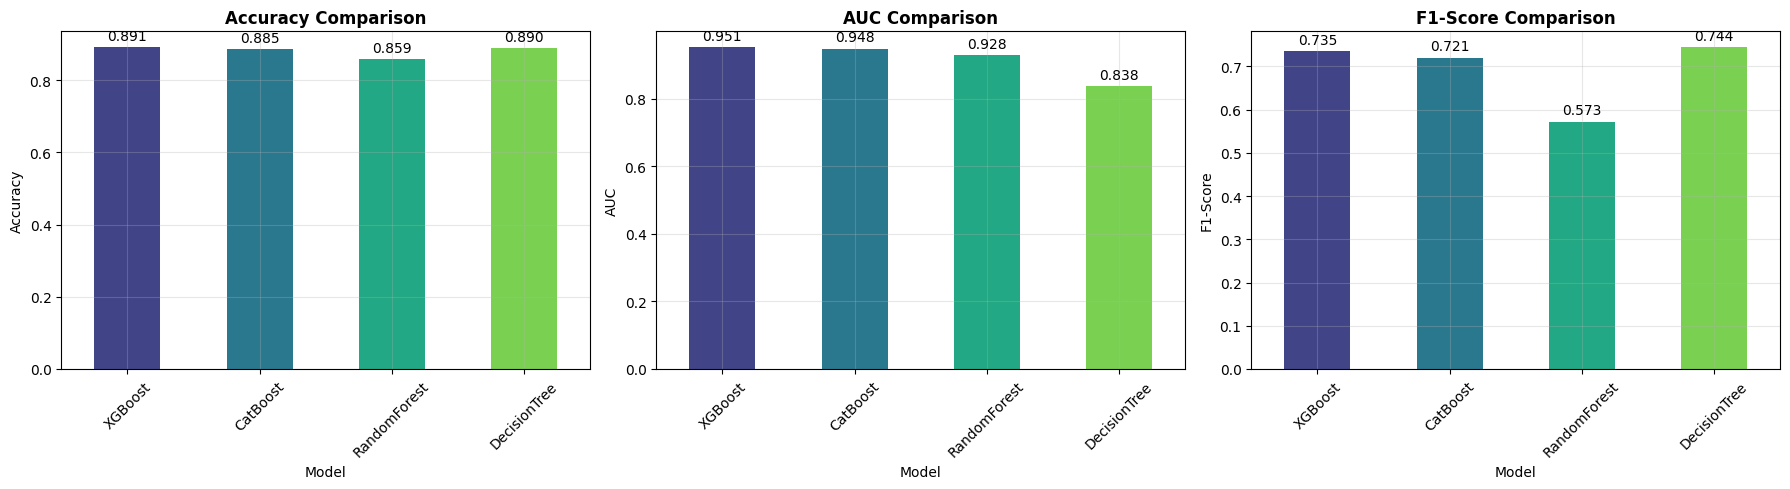

In [50]:
# Compare model performance
results_df = pd.DataFrame(results).T
print("\nModel Performance Comparison:")
print(results_df.round(4))

# Define a color palette
palette = sns.color_palette("viridis", n_colors=len(results_df))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['Accuracy', 'AUC', 'F1-Score']
for idx, metric in enumerate(metrics):
    results_df[metric].plot(kind='bar', ax=axes[idx], color=palette)
    axes[idx].set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(metric, fontsize=10)
    axes[idx].set_xlabel('Model', fontsize=10)
    axes[idx].set_xticklabels(results_df.index, rotation=45)
    axes[idx].grid(alpha=0.3)

    # Add value labels
    for container in axes[idx].containers:
        axes[idx].bar_label(container, fmt='%.3f', padding=3)

plt.tight_layout()
plt.show()